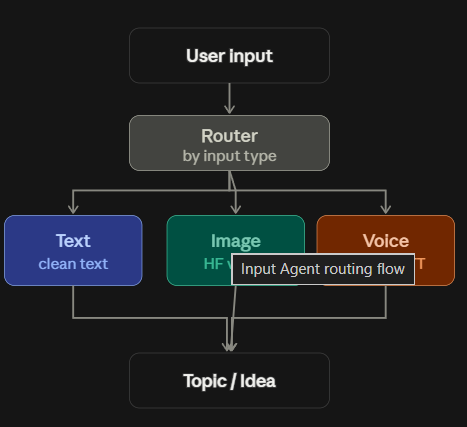

In [2]:
from typing import TypedDict, Literal
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END

load_dotenv()

class InputState(TypedDict):
    input_type: Literal["text", "image", "voice"]
    raw_input: str          # text, image path, ya audio path
    topic: str              # final output jo Script Agent ko jayega

# Node 1: Text ko seedha aage bhej do (thoda cleaning kar sakta hai)
def text_node(state: InputState) -> dict:
    return {"topic": state["raw_input"].strip()}

# Node 2: HuggingFace vision model se image ko caption me convert karo
def image_node(state: InputState) -> dict:
    from huggingface_hub import InferenceClient
    client = InferenceClient()
    caption = client.image_to_text(state["raw_input"], model="Salesforce/blip-image-captioning-large")
    return {"topic": caption}

# Node 3: Google STT se voice ko text me convert karo
def voice_node(state: InputState) -> dict:
    import speech_recognition as sr
    r = sr.Recognizer()
    with sr.AudioFile(state["raw_input"]) as source:
        audio = r.record(source)
    text = r.recognize_google(audio)
    return {"topic": text}

# Router: decide karega konsa node chalega
def route_input(state: InputState) -> str:
    return state["input_type"]

builder = StateGraph(InputState)
builder.add_node("text_node", text_node)
builder.add_node("image_node", image_node)
builder.add_node("voice_node", voice_node)

builder.add_conditional_edges(
    START,
    route_input,
    {"text": "text_node", "image": "image_node", "voice": "voice_node"}
)

builder.add_edge("text_node", END)
builder.add_edge("image_node", END)
builder.add_edge("voice_node", END)

input_agent = builder.compile()

# Test
result = input_agent.invoke({"input_type": "text", "raw_input": "make a video on AI in agriculture"})
print(result["topic"])

make a video on AI in agriculture


In [3]:
from fastapi import FastAPI, UploadFile, Form
from typing import Optional
import shutil, uuid, os

app = FastAPI()

@app.post("/generate")
async def generate(
    input_type: str = Form(...),          
    text: Optional[str] = Form(None),      
    file: Optional[UploadFile] = None      
):
    raw_input = None

    if input_type == "text":
        raw_input = text

    elif input_type in ("image", "voice"):
        # file ko temp folder me save, path Input Agent ko 
        ext = os.path.splitext(file.filename)[1]
        temp_path = f"temp/{uuid.uuid4()}{ext}"
        with open(temp_path, "wb") as buffer:
            shutil.copyfileobj(file.file, buffer)
        raw_input = temp_path

    # LangGraph Input Agent call 
    result = input_agent.invoke({
        "input_type": input_type,
        "raw_input": raw_input
    })

    return {"topic": result["topic"]}

# Router Function

In [4]:
def route_input(state: InputState) -> str:
    return state["input_type"]

# Mapping dict jo decide karta hai kahan jana hai

In [5]:
builder.add_conditional_edges(
    START,
    route_input,
    {
        "text": "text_node",
        "image": "image_node",
        "voice": "voice_node"input_agent.invoke({"input_type": "image", "raw_input": "photo.jpg"})
    }
)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2919114282.py, line 7)

In [ ]:
input_agent.invoke({"input_type": "image", "raw_input": "photo.jpg"})

In [ ]:
def route_input(state: InputState) -> str:
    raw = state["raw_input"]

    if state.get("input_type"):
        return state["input_type"]          # agar explicitly diya hai, wahi use karo

    if raw.lower().endswith((".jpg", ".jpeg", ".png", ".webp")):
        return "image"
    elif raw.lower().endswith((".mp3", ".wav", ".m4a")):
        return "voice"
    else:
        return "text"

# Basic cleaning

In [ ]:
import re

def clean_text(raw: str) -> str:
    if not raw or not raw.strip():
        raise ValueError("Input text khali hai")

    text = raw.strip()
    text = re.sub(r'\s+', ' ', text)      
    text = re.sub(r'[\x00-\x1f\x7f]', '', text)  

    if len(text) > 2000:                     
        text = text[:2000]

    return text

# Topic normalization

In [ ]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.1)

def normalize_topic(text: str) -> str:
    prompt = (
        "Convert the following user request into a single clear video topic. "
        "Remove filler words and conversational phrasing. "
        "Return ONLY the topic in one line, nothing else.\n\n"
        f"User input:\n{text}"
    )
    response = llm.invoke(prompt)
    return response.content.strip()

In [6]:
def text_node(state: InputState) -> dict:
    raw = state["raw_input"]
    cleaned = clean_text(raw)
    if len(cleaned.split()) > 8:
        topic = normalize_topic(cleaned)
    else:
        topic = cleaned   
    return {"topic": topic}

# HuggingFace vision model

In [10]:
import os
from huggingface_hub import InferenceClient
from dotenv import load_dotenv

load_dotenv()

client = InferenceClient(token=os.getenv("HF_TOKEN"))

def image_node(state: InputState) -> dict:
    image_path = state["raw_input"]

    try:
        with open(image_path, "rb") as f:
            image_bytes = f.read()

        caption = client.image_to_text(
            image_bytes,
            model="Salesforce/blip-image-captioning-large"
        )

        # Response object ya plain string dono aa sakta hai (version ke hisab se)
        text = caption.generated_text if hasattr(caption, "generated_text") else str(caption)

    except Exception as e:
        raise RuntimeError(f"Image captioning fail hua: {e}")

    return {"topic": normalize_topic(text)}

In [11]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image

# Ye ek baar load hoga, module level pe rakho (har call pe mat karo)
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

def image_node(state: InputState) -> dict:
    image = Image.open(state["raw_input"]).convert("RGB")

    inputs = processor(image, return_tensors="pt")
    output = model.generate(**inputs, max_new_tokens=50)
    caption = processor.decode(output[0], skip_special_tokens=True)

    return {"topic": normalize_topic(caption)}

Loading weights: 100%|██████████| 473/473 [00:00<00:00, 6870.86it/s]


In [ ]:
result = input_agent.invoke({
    "input_type": "image",
    "raw_input": "temp/farm.jpg"
})

In [ ]:
prompt = (
    "An image shows the following scene. Suggest a short, engaging video topic "
    "based on it. Return ONLY the topic in one line.\n\n"
    f"Scene: {caption}"
)

# Speech to Text

In [ ]:
import speech_recognition as sr
from pydub import AudioSegment
import os

def convert_to_wav(audio_path: str) -> str:
    """Google STT sirf WAV/FLAC leta hai — mp3/m4a ko convert karna padega"""
    if audio_path.lower().endswith(".wav"):
        return audio_path

    wav_path = os.path.splitext(audio_path)[0] + ".wav"
    audio = AudioSegment.from_file(audio_path)
    audio = audio.set_channels(1).set_frame_rate(16000)  
    audio.export(wav_path, format="wav")
    return wav_path


def voice_node(state: InputState) -> dict:
    audio_path = state["raw_input"]
    wav_path = convert_to_wav(audio_path)

    recognizer = sr.Recognizer()

    try:
        with sr.AudioFile(wav_path) as source:
            recognizer.adjust_for_ambient_noise(source, duration=0.5)  # background noise handle
            audio_data = recognizer.record(source)

        # language: "en-IN" Indian English, "hi-IN" Hindi
        text = recognizer.recognize_google(audio_data, language="hi-IN")

    except sr.UnknownValueError:
        raise ValueError("Audio samajh nahi aaya — clear bol kar dobara try karo")
    except sr.RequestError as e:
        raise RuntimeError(f"Google STT service se connect nahi hua: {e}")
    finally:
        # temp wav cleanup
        if wav_path != audio_path and os.path.exists(wav_path):
            os.remove(wav_path)

    return {"topic": normalize_topic(text)}

c:\Great_Productions\Vision_Fly\Vison_Fly\Lib\site-packages\pydub\utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


# Google Cloud STT

In [16]:
from google.cloud import speech

def voice_node(state: InputState) -> dict:
    wav_path = convert_to_wav(state["raw_input"])
    client = speech.SpeechClient()

    with open(wav_path, "rb") as f:
        content = f.read()

    audio = speech.RecognitionAudio(content=content)
    config = speech.RecognitionConfig(
        encoding=speech.RecognitionConfig.AudioEncoding.LINEAR16,
        sample_rate_hertz=16000,
        language_code="hi-IN",
        alternative_language_codes=["en-IN"],   # ye Hinglish ke liye kaafi useful hai
        enable_automatic_punctuation=True,
    )

    response = client.recognize(config=config, audio=audio)
    text = " ".join([r.alternatives[0].transcript for r in response.results])

    return {"topic": normalize_topic(text)}

In [ ]:
result = input_agent.invoke({
    "input_type": "voice",
    "raw_input": "temp/user_voice.mp3"
})

# INPUT -- AGENT 💯

In [18]:
"""
Input Agent — Multi-agent Video Generation Pipeline
Text / Image / Voice input ko clean "Topic/Idea" text me convert karta hai,
jo aage Script Agent ko feed hota hai.
"""

import os
import re
from typing import TypedDict, Literal, Optional

from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq

load_dotenv()

# ─────────────────────────────────────────────
# Shared LLM (topic normalization ke liye)
# ─────────────────────────────────────────────
llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0.1)


def normalize_topic(text: str) -> str:
    """Raw text/caption/transcript ko clean, video-worthy topic me convert karta hai."""
    prompt = (
        "Convert the following user request into a single clear video topic. "
        "Remove filler words and conversational phrasing. "
        "Return ONLY the topic in one line, nothing else.\n\n"
        f"User input:\n{text}"
    )
    response = llm.invoke(prompt)
    return response.content.strip()


# ─────────────────────────────────────────────
# State
# ─────────────────────────────────────────────
class InputState(TypedDict):
    input_type: Optional[Literal["text", "image", "voice"]]
    raw_input: str      # text string, image path, ya audio path
    topic: str          # final output — Script Agent ko yahi milega


# ─────────────────────────────────────────────
# Node: Text
# ─────────────────────────────────────────────
def clean_text(raw: str) -> str:
    if not raw or not raw.strip():
        raise ValueError("Input text khali hai")

    text = raw.strip()
    text = re.sub(r"\s+", " ", text)                  # multiple spaces/newlines -> single space
    text = re.sub(r"[\x00-\x1f\x7f]", "", text)        # invisible control chars hatao

    if len(text) > 2000:
        text = text[:2000]

    return text


def text_node(state: InputState) -> dict:
    print("\n[Text branch] Cleaning text input...")
    cleaned = clean_text(state["raw_input"])

    # chhote clean inputs pe LLM call waste mat karo
    if len(cleaned.split()) > 8:
        topic = normalize_topic(cleaned)
    else:
        topic = cleaned

    return {"topic": topic}


# ─────────────────────────────────────────────
# Node: Image (HuggingFace vision)
# ─────────────────────────────────────────────
def image_node(state: InputState) -> dict:
    print("\n[Image branch] Generating caption via HuggingFace...")
    from huggingface_hub import InferenceClient

    client = InferenceClient(token=os.getenv("HF_TOKEN"))
    image_path = state["raw_input"]

    try:
        with open(image_path, "rb") as f:
            image_bytes = f.read()

        caption = client.image_to_text(
            image_bytes,
            model="Salesforce/blip-image-captioning-large",
        )
        text = caption.generated_text if hasattr(caption, "generated_text") else str(caption)

    except Exception as e:
        raise RuntimeError(f"Image captioning fail hua: {e}")

    return {"topic": normalize_topic(text)}


# ─────────────────────────────────────────────
# Node: Voice (Google STT)
# ─────────────────────────────────────────────
def convert_to_wav(audio_path: str) -> str:
    """Google STT sirf WAV/FLAC leta hai — mp3/m4a ko convert karna padega."""
    if audio_path.lower().endswith(".wav"):
        return audio_path

    from pydub import AudioSegment

    wav_path = os.path.splitext(audio_path)[0] + ".wav"
    audio = AudioSegment.from_file(audio_path)
    audio = audio.set_channels(1).set_frame_rate(16000)
    audio.export(wav_path, format="wav")
    return wav_path


def voice_node(state: InputState) -> dict:
    print("\n[Voice branch] Transcribing audio via Google STT...")
    import speech_recognition as sr

    audio_path = state["raw_input"]
    wav_path = convert_to_wav(audio_path)
    recognizer = sr.Recognizer()

    try:
        with sr.AudioFile(wav_path) as source:
            recognizer.adjust_for_ambient_noise(source, duration=0.5)
            audio_data = recognizer.record(source)

        # hi-IN Hinglish ko sabse acche se handle karta hai
        text = recognizer.recognize_google(audio_data, language="hi-IN")

    except sr.UnknownValueError:
        raise ValueError("Audio samajh nahi aaya — clear bol kar dobara try karo")
    except sr.RequestError as e:
        raise RuntimeError(f"Google STT service se connect nahi hua: {e}")
    finally:
        if wav_path != audio_path and os.path.exists(wav_path):
            os.remove(wav_path)

    return {"topic": normalize_topic(text)}


# ─────────────────────────────────────────────
# Router
# ─────────────────────────────────────────────
def route_input(state: InputState) -> str:
    if state.get("input_type"):
        return state["input_type"]

    # fallback: agar input_type nahi diya, extension se detect karo
    raw = state["raw_input"].lower()
    if raw.endswith((".jpg", ".jpeg", ".png", ".webp")):
        return "image"
    elif raw.endswith((".mp3", ".wav", ".m4a")):
        return "voice"
    return "text"


# ─────────────────────────────────────────────
# Graph
# ─────────────────────────────────────────────
builder = StateGraph(InputState)

builder.add_node("text_node", text_node)
builder.add_node("image_node", image_node)
builder.add_node("voice_node", voice_node)

builder.add_conditional_edges(
    START,
    route_input,
    {"text": "text_node", "image": "image_node", "voice": "voice_node"},
)

builder.add_edge("text_node", END)
builder.add_edge("image_node", END)
builder.add_edge("voice_node", END)

input_agent = builder.compile()


# ─────────────────────────────────────────────
# Test
# ─────────────────────────────────────────────
if __name__ == "__main__":
    # 1. Text test
    result = input_agent.invoke({
        "input_type": "text",
        "raw_input": "bhai ek video banao AI ke baare me farming me kaise use hota hai",
    })
    print("\nFinal topic (text):", result["topic"])

    # 2. Image test (uncomment aur path daal)
    # result = input_agent.invoke({"input_type": "image", "raw_input": "temp/farm.jpg"})
    # print("\nFinal topic (image):", result["topic"])

    # 3. Voice test (uncomment aur path daal)
    # result = input_agent.invoke({"input_type": "voice", "raw_input": "temp/voice.mp3"})
    # print("\nFinal topic (voice):", result["topic"])


[Text branch] Cleaning text input...

Final topic (text): AI in Agriculture: How It Is Used in Farming
